# Land Cover Classification Validation

This notebook validates the HydraNet land-cover (`lc`) decoder on the PhilEOBench land-cover classification dataset from Hugging Face.

The dataset is distributed as a zipped Zarr archive, not as Dataset Viewer parquet rows. The notebook therefore makes the data staging explicit: it checks the archive size, reuses an extracted local Zarr when possible, and only downloads/extracts the 3.69 GB archive when `AUTO_DOWNLOAD=True`.

The task contract is semantic segmentation: an 8-channel PhiSat-style image tile goes into the model and an 11-class land-cover mask comes out.


## Class, Data, And Model Contract

The labels follow the ESA WorldCover code scheme. The decoder output channels are treated as the same classes in ascending code order, so code `10` maps to channel `0`, code `20` maps to channel `1`, and so on through code `100`.

Keep `TRAINING`, `N_SHOTS`, and `MODEL_TASK` aligned with the checkpoint catalog in `src/hydranet/model_weights.csv`.


In [1]:
from pathlib import Path

import numpy as np

DATASET_REPO = "ESA-PhiLab-Edge/PhilEOBench-land_cover_classification"
ARCHIVE_NAME = "phileo-bench_lc.zarr.zip"
ZARR_NAME = "phileo-bench_lc.zarr"
MODEL_TASK = "lc"
TRAINING = "linear_probing"
N_SHOTS = 50
CHECKPOINT_DATETIME = 20251228
MODEL_INPUT_SIZE = 224
TILE_STRIDE = 112
N_SAMPLES = 8
MODEL_CLASS_ORDER_SOURCE = "Phi2FM downstream/utils/config_lc.py lc_model_map: WorldCover ascending code order"
CHECKPOINT_AUDIT_LOCAL_ONLY = True
CHECKPOINT_AUDIT_COMBOS = (
    ("finetuning", 5000),
    ("linear_probing", 50),
    ("linear_probing", 100),
    ("linear_probing", 500),
    ("linear_probing", 1000),
    ("linear_probing", 5000),
)
ARTIFACT_AUDIT_NORMALIZATION_MODES = (
    "as_stored",
    "divide_10000",
    "per_tile_channel_standardization",
    "phisatnet_lc_training",
)
SMOOTHING_AUDIT_KERNELS = (0, 3, 5, 7)
SMOOTHED_PREVIEW_KERNEL = 5
PREDICTION_SMOOTHING_KERNEL = 5

# The source archive is about 3.69 GB. Extraction needs extra space.
AUTO_DOWNLOAD = True
VALIDATION_GROUP = "test"
DATA_ROOT = Path.home() / ".cache" / "hydranet" / "land_cover"
ARCHIVE_PATH = DATA_ROOT / ARCHIVE_NAME
ZARR_PATH = DATA_ROOT / ZARR_NAME
OUTPUT_DIR = DATA_ROOT / "outputs"
WEIGHTS_DIR = DATA_ROOT / "weights"

# Sentinel-2 true-color display from the stored B1-B8 order used by the other decoder notebooks.
RGB_BANDS = (3, 2, 1)
NORMALIZATION_MODE = "phisatnet_lc_training"
MISSING_CONVNEXT_GAMMA = "ones"
FILL_VALUE = 65535.0
MAX_FILL_FRACTION = 0.05
ZARR_MARKERS = (".zgroup", "zarr.json")

PHISAT_MIN = np.array([0., 0., 0., 0., 0., 0., 0., 0.], dtype=np.float32)
PHISAT_MAX = np.array([100., 100., 100., 100., 100., 100., 100., 100.], dtype=np.float32)
PHISAT_MEAN = np.array([39.91732045, 37.5492021, 37.54950869, 39.21091477, 44.2665634, 39.50358262, 43.62563718, 45.28759192], dtype=np.float32)
PHISAT_STD = np.array([17.06368142, 17.08672835, 20.21215486, 17.8629414, 20.11975944, 20.02886564, 19.79381833, 20.16760416], dtype=np.float32)

WORLD_COVER_CLASSES = (
    (10, "Tree Cover", (0.00, 0.39, 0.00)),
    (20, "Shrubland", (0.72, 0.54, 0.04)),
    (30, "Grassland", (0.85, 0.80, 0.30)),
    (40, "Cropland", (0.95, 0.65, 0.25)),
    (50, "Built-up", (0.75, 0.12, 0.12)),
    (60, "Bare/Sparse Vegetation", (0.78, 0.72, 0.62)),
    (70, "Snow and Ice", (0.80, 0.90, 1.00)),
    (80, "Permanent Water Bodies", (0.05, 0.25, 0.70)),
    (90, "Herbaceous Wetland", (0.45, 0.75, 0.55)),
    (95, "Mangroves", (0.00, 0.45, 0.35)),
    (100, "Moss and Lichen", (0.70, 0.55, 0.80)),
)
CLASS_CODES = tuple(code for code, _, _ in WORLD_COVER_CLASSES)
CLASS_NAMES = tuple(name for _, name, _ in WORLD_COVER_CLASSES)
CLASS_COLORS = tuple(color for _, _, color in WORLD_COVER_CLASSES)
CODE_TO_CLASS_ID = {code: idx for idx, code in enumerate(CLASS_CODES)}
IGNORE_INDEX = 255


def looks_like_zarr_store(path: Path) -> bool:
    return path.is_dir() and any((path / marker).exists() for marker in ZARR_MARKERS)


DATA_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"dataset_repo: {DATASET_REPO}")
print(f"archive_path: {ARCHIVE_PATH}")
print(f"zarr_path: {ZARR_PATH}")
print(f"model: task={MODEL_TASK}, training={TRAINING}, n_shots={N_SHOTS}, checkpoint_datetime={CHECKPOINT_DATETIME}")
print(f"classes: {len(CLASS_NAMES)}")
print(f"normalization_mode: {NORMALIZATION_MODE}")
print(f"missing_convnext_gamma: {MISSING_CONVNEXT_GAMMA}")
print(f"prediction_smoothing_kernel: {PREDICTION_SMOOTHING_KERNEL}")
print(f"class_order_source: {MODEL_CLASS_ORDER_SOURCE}")
print(f"checkpoint_audit_local_only: {CHECKPOINT_AUDIT_LOCAL_ONLY}")


dataset_repo: ESA-PhiLab-Edge/PhilEOBench-land_cover_classification
archive_path: /Users/roberto.delprete/.cache/hydranet/land_cover/phileo-bench_lc.zarr.zip
zarr_path: /Users/roberto.delprete/.cache/hydranet/land_cover/phileo-bench_lc.zarr
model: task=lc, training=linear_probing, n_shots=50, checkpoint_datetime=20251228
classes: 11
normalization_mode: phisatnet_lc_training
missing_convnext_gamma: ones
prediction_smoothing_kernel: 5
class_order_source: Phi2FM downstream/utils/config_lc.py lc_model_map: WorldCover ascending code order
checkpoint_audit_local_only: True


## Download And Extract The Zarr Archive

The Hugging Face Dataset Viewer reports no supported preview rows for this repository because the payload is a zipped Zarr. This cell keeps the heavy operation behind a preflight and reuses existing local files.


In [2]:
import shutil
import zipfile
from huggingface_hub import HfApi, hf_hub_download

EXTRACTION_MULTIPLIER = 2.2
FALLBACK_ARCHIVE_BYTES = int(3.7 * 1024**3)


def bytes_to_gib(value: int) -> float:
    return value / 1024**3


def remote_archive_size_bytes(repo_id: str, filename: str) -> int:
    try:
        info = HfApi().dataset_info(repo_id=repo_id, files_metadata=True)
        for sibling in info.siblings:
            if getattr(sibling, "rfilename", None) == filename and getattr(sibling, "size", None):
                return int(sibling.size)
    except Exception as exc:
        print(f"Could not query remote archive size; using fallback estimate. Reason: {exc}")
    return FALLBACK_ARCHIVE_BYTES


def find_zarr_store(root: Path):
    candidates = [ZARR_PATH, root / ZARR_NAME, root]
    for candidate in candidates:
        if looks_like_zarr_store(candidate):
            return candidate
    for candidate in sorted(root.glob("*.zarr")):
        if looks_like_zarr_store(candidate):
            return candidate
    return None


archive_bytes = remote_archive_size_bytes(DATASET_REPO, ARCHIVE_NAME)
free_bytes = shutil.disk_usage(DATA_ROOT).free
existing_zarr = find_zarr_store(DATA_ROOT)
print(f"remote archive size: {bytes_to_gib(archive_bytes):.2f} GiB")
print(f"available free space: {bytes_to_gib(free_bytes):.1f} GiB")

if existing_zarr is not None:
    ZARR_PATH = existing_zarr
    print(f"Using existing Zarr store: {ZARR_PATH}")
else:
    required_bytes = int(archive_bytes * EXTRACTION_MULTIPLIER)
    print(f"recommended free space before download/extract: {bytes_to_gib(required_bytes):.1f} GiB")
    if not AUTO_DOWNLOAD:
        raise FileNotFoundError(f"No extracted Zarr found under {DATA_ROOT}. Set AUTO_DOWNLOAD=True or set ZARR_PATH manually.")
    if free_bytes < required_bytes:
        raise RuntimeError(
            "Not enough free space for the land-cover archive and extracted Zarr. "
            f"Need about {bytes_to_gib(required_bytes):.1f} GiB, found {bytes_to_gib(free_bytes):.1f} GiB."
        )

    if not ARCHIVE_PATH.exists():
        downloaded = hf_hub_download(
            repo_id=DATASET_REPO,
            repo_type="dataset",
            filename=ARCHIVE_NAME,
            local_dir=DATA_ROOT,
        )
        ARCHIVE_PATH = Path(downloaded)
        print(f"Downloaded archive: {ARCHIVE_PATH}")
    else:
        print(f"Using existing archive: {ARCHIVE_PATH}")

    print("Extracting archive. This can take several minutes.")
    with zipfile.ZipFile(ARCHIVE_PATH) as archive:
        archive.extractall(DATA_ROOT)

    extracted = find_zarr_store(DATA_ROOT)
    if extracted is None:
        raise FileNotFoundError(f"Extraction completed, but no Zarr store was found under {DATA_ROOT}")
    ZARR_PATH = extracted
    print(f"Extracted Zarr store: {ZARR_PATH}")


remote archive size: 3.44 GiB
available free space: 135.6 GiB
Using existing Zarr store: /Users/roberto.delprete/.cache/hydranet/land_cover


## Open The Zarr Store

The resolver accepts both flat sample groups and split groups such as `train`, `val`, `validation`, or `test`.


In [3]:
import zarr

root = zarr.open_group(str(ZARR_PATH), mode="r")
print("root keys:", list(root.keys())[:20])


def child_groups(group) -> dict[str, object]:
    groups = {}
    for name in group.keys():
        try:
            child = group[name]
        except Exception:
            continue
        if hasattr(child, "keys"):
            groups[name] = child
    return groups


def group_contains_samples(group) -> bool:
    for name, child in child_groups(group).items():
        keys = set(child.keys()) if hasattr(child, "keys") else set()
        if {"img", "label"}.issubset(keys) or {"image", "label"}.issubset(keys):
            return True
    return False


def resolve_sample_container(root_group, preferred_group: str):
    groups = child_groups(root_group)
    lower_to_name = {name.lower(): name for name in groups}
    preferred_names = tuple(dict.fromkeys((preferred_group.lower(), "val", "validation", "valid", "test", "trainval", "train_val", "train")))

    for wanted in preferred_names:
        if wanted in lower_to_name:
            name = lower_to_name[wanted]
            return groups[name], name

    for name, group in groups.items():
        if group_contains_samples(group):
            return group, name

    if group_contains_samples(root_group):
        return root_group, "<root>"

    raise ValueError("Could not find a sample container with img/image and label children.")


sample_group, sample_group_name = resolve_sample_container(root, VALIDATION_GROUP)
all_sample_ids = tuple(sorted(name for name, child in child_groups(sample_group).items()))


def image_channel_count(sample) -> int:
    image = sample["img"] if "img" in sample else sample["image"]
    shape = image.shape
    if len(shape) != 3:
        return 0
    if shape[0] <= 32:
        return int(shape[0])
    if shape[-1] <= 32:
        return int(shape[-1])
    return 0


sample_ids = tuple(sample_id for sample_id in all_sample_ids if image_channel_count(sample_group[sample_id]) >= 8)
print(f"selected sample group: {sample_group_name}")
print(f"sample count: {len(all_sample_ids)}")
print(f"8-channel image sample count: {len(sample_ids)}")
print("first 8-channel sample ids:", sample_ids[:10])


root keys: ['trainval']


selected sample group: trainval
sample count: 1049
8-channel image sample count: 6
first 8-channel sample ids: ('0000000', '0000001', '0000002', '0000003', '0000004', '0000005')


## Sample Loading Helpers

The helper code decodes WorldCover label codes to contiguous model ids, selects informative 224 x 224 crops, and leaves the image values unchanged by default.


In [4]:
import numpy as np


def to_chw(image: np.ndarray) -> np.ndarray:
    image = np.asarray(image)
    if image.ndim != 3:
        raise ValueError(f"Expected image with 3 dimensions, got shape {image.shape}")
    if image.shape[0] <= 32:
        return image.astype(np.float32, copy=False)
    if image.shape[-1] <= 32:
        return np.moveaxis(image, -1, 0).astype(np.float32, copy=False)
    raise ValueError(f"Could not infer channel axis from image shape {image.shape}")


def squeeze_label(label: np.ndarray) -> np.ndarray:
    label = np.asarray(label)
    if label.ndim == 3 and 1 in (label.shape[0], label.shape[-1]):
        label = label[0] if label.shape[0] == 1 else label[..., 0]
    return label


def decode_worldcover_label(label: np.ndarray) -> np.ndarray:
    label = squeeze_label(label)
    if label.ndim == 3:
        if label.shape[0] == len(CLASS_NAMES) and label.shape[0] < label.shape[-1]:
            return label.argmax(axis=0).astype(np.uint8)
        if label.shape[-1] == len(CLASS_NAMES):
            return label.argmax(axis=-1).astype(np.uint8)
        raise ValueError(f"Could not decode multi-channel label shape {label.shape}")
    if label.ndim != 2:
        raise ValueError(f"Expected 2D land-cover label, got shape {label.shape}")

    values = set(np.unique(label).astype(int).tolist())
    if values.issubset(set(range(len(CLASS_NAMES))) | {IGNORE_INDEX}):
        return label.astype(np.uint8, copy=False)

    decoded = np.full(label.shape, IGNORE_INDEX, dtype=np.uint8)
    for code, class_id in CODE_TO_CLASS_ID.items():
        decoded[label == code] = class_id
    unknown = set(np.unique(decoded).astype(int).tolist()) - set(range(len(CLASS_NAMES))) - {IGNORE_INDEX}
    if unknown:
        raise ValueError(f"Unexpected decoded class ids: {sorted(unknown)}")
    if np.all(decoded == IGNORE_INDEX):
        raise ValueError(f"No WorldCover codes were recognized. Raw values were: {sorted(values)[:20]}")
    return decoded


def read_array(sample, *names):
    for name in names:
        if name in sample:
            return np.asarray(sample[name])
    raise KeyError(f"None of {names} were found in sample keys: {list(sample.keys())}")


def read_spatial_window(array, top: int, left: int, size: int) -> np.ndarray:
    shape = array.shape
    if len(shape) == 2:
        return np.asarray(array[top:top + size, left:left + size])
    if len(shape) == 3 and shape[0] <= 32:
        return np.asarray(array[:, top:top + size, left:left + size])
    if len(shape) == 3 and shape[-1] <= 32:
        return np.asarray(array[top:top + size, left:left + size, :])
    raise ValueError(f"Unsupported array shape for spatial windowing: {shape}")


def valid_reflectance_mask(image_chw: np.ndarray) -> np.ndarray:
    finite = np.isfinite(image_chw)
    not_fill = image_chw < FILL_VALUE
    return np.all(finite & not_fill, axis=0)


def fill_fraction(image_chw: np.ndarray) -> float:
    return 1.0 - float(valid_reflectance_mask(image_chw).mean())


def class_fractions(label: np.ndarray) -> np.ndarray:
    valid = label != IGNORE_INDEX
    if not np.any(valid):
        return np.zeros(len(CLASS_NAMES), dtype=np.float32)
    counts = np.bincount(label[valid].reshape(-1), minlength=len(CLASS_NAMES))[:len(CLASS_NAMES)]
    return counts.astype(np.float32) / float(valid.sum())


def window_origins(length: int, size: int, stride: int) -> list[int]:
    if length < size:
        raise ValueError(f"Cannot crop dimension {length} to {size}")
    origins = list(range(0, length - size + 1, stride))
    last = length - size
    if origins[-1] != last:
        origins.append(last)
    return origins


def select_crop_window(image_array, label: np.ndarray, size: int, stride: int) -> tuple[int, int, np.ndarray, float]:
    best = None
    for top in window_origins(label.shape[0], size, stride):
        for left in window_origins(label.shape[1], size, stride):
            image_crop = to_chw(read_spatial_window(image_array, top, left, size))
            crop_fill_fraction = fill_fraction(image_crop[:8])
            if crop_fill_fraction > MAX_FILL_FRACTION:
                continue
            crop = label[top:top + size, left:left + size]
            fractions = class_fractions(crop)
            present = fractions[fractions > 0]
            if len(present) == 0:
                continue
            entropy = -float(np.sum(present * np.log(present)))
            coverage = float((crop != IGNORE_INDEX).mean())
            score = entropy + 0.25 * coverage - crop_fill_fraction
            if best is None or score > best[0]:
                best = (score, top, left, fractions, crop_fill_fraction)
    if best is None:
        raise ValueError(f"No valid {size}x{size} crop found with fill_fraction <= {MAX_FILL_FRACTION}")
    _, top, left, fractions, crop_fill_fraction = best
    return top, left, fractions, crop_fill_fraction


def prepare_model_input(image_chw: np.ndarray, mode=None) -> np.ndarray:
    mode = NORMALIZATION_MODE if mode is None else mode
    image = image_chw.astype(np.float32, copy=True)
    image[image >= FILL_VALUE] = np.nan
    if mode == "as_stored":
        return np.nan_to_num(image, nan=0.0)
    if mode == "divide_10000":
        return np.nan_to_num(np.clip(image, 0.0, 10000.0) / 10000.0, nan=0.0)
    if mode == "per_tile_channel_standardization":
        mean = np.nanmean(image, axis=(1, 2), keepdims=True)
        std = np.nanstd(image, axis=(1, 2), keepdims=True)
        standardized = (image - mean) / np.maximum(std, 1e-6)
        return np.nan_to_num(standardized, nan=0.0)
    if mode == "phisatnet_lc_training":
        # Matches phi2FM downstream/utils/load_data.py callback_preprocess_phisatnet_lc.
        image = np.sqrt(np.maximum(image, 0.0))
        image = np.clip(image, PHISAT_MIN[:, None, None], PHISAT_MAX[:, None, None])
        normalized = (image - PHISAT_MEAN[:, None, None]) / PHISAT_STD[:, None, None]
        return np.nan_to_num(normalized, nan=0.0)
    raise ValueError(f"Unsupported normalization mode: {mode}")


## Load Samples

The crop selector prefers windows with multiple visible classes so the visual and numerical checks are more informative than a mostly single-class tile.


In [5]:
def read_sample(sample_id: str) -> dict:
    sample = sample_group[sample_id]
    image_array = read_array(sample, "img", "image")
    label_array = read_array(sample, "label", "mask", "target")

    if image_channel_count(sample) < 8:
        raise ValueError(f"Sample {sample_id} has image shape {image_array.shape}; expected at least 8 channels")

    full_label = decode_worldcover_label(np.asarray(label_array))
    top, left, fractions, crop_fill_fraction = select_crop_window(image_array, full_label, MODEL_INPUT_SIZE, TILE_STRIDE)
    image = to_chw(read_spatial_window(image_array, top, left, MODEL_INPUT_SIZE))
    label = decode_worldcover_label(read_spatial_window(label_array, top, left, MODEL_INPUT_SIZE))
    model_input = prepare_model_input(image[:8])
    return {
        "sample_id": sample_id,
        "image": image,
        "label": label,
        "model_input": model_input,
        "crop_origin": (top, left),
        "class_fractions": fractions,
        "fill_fraction": crop_fill_fraction,
    }


if len(sample_ids) == 0:
    raise RuntimeError(f"No 8-channel image samples found in group {sample_group_name!r}")

records = []
skipped = []
for sample_id in sample_ids:
    if len(records) >= N_SAMPLES:
        break
    try:
        records.append(read_sample(sample_id))
    except Exception as exc:
        skipped.append((sample_id, str(exc)))

if len(records) == 0:
    raise RuntimeError(f"No valid 8-channel samples could be loaded; skipped first failures: {skipped[:5]}")
if len(records) < N_SAMPLES:
    print(f"requested {N_SAMPLES} samples, but only {len(records)} valid 8-channel samples are usable; skipped first failures: {skipped[:5]}")

print(f"loaded {len(records)} valid 8-channel samples; skipped {len(skipped)} candidates")
for record in records:
    visible = {
        CLASS_NAMES[idx]: round(float(frac), 4)
        for idx, frac in enumerate(record["class_fractions"])
        if frac > 0
    }
    print(
        record["sample_id"],
        "image", record["image"].shape,
        "label", record["label"].shape,
        "crop", record["crop_origin"],
        "fill", round(record["fill_fraction"], 4),
        visible,
    )


requested 8 samples, but only 5 valid 8-channel samples are usable; skipped first failures: [('0000003', 'No valid 224x224 crop found with fill_fraction <= 0.05')]
loaded 5 valid 8-channel samples; skipped 1 candidates
0000000 image (8, 224, 224) label (224, 224) crop (4816, 672) fill 0.0 {'Tree Cover': 0.1014, 'Grassland': 0.1738, 'Cropland': 0.0011, 'Built-up': 0.1765, 'Bare/Sparse Vegetation': 0.0121, 'Permanent Water Bodies': 0.3209, 'Herbaceous Wetland': 0.2142}
0000001 image (8, 224, 224) label (224, 224) crop (2352, 2464) fill 0.0 {'Tree Cover': 0.2123, 'Grassland': 0.2583, 'Cropland': 0.2362, 'Built-up': 0.283, 'Bare/Sparse Vegetation': 0.0102}
0000002 image (8, 224, 224) label (224, 224) crop (1232, 112) fill 0.0 {'Tree Cover': 0.0654, 'Grassland': 0.1751, 'Cropland': 0.2427, 'Permanent Water Bodies': 0.2523, 'Herbaceous Wetland': 0.2645}
0000004 image (8, 224, 224) label (224, 224) crop (4256, 112) fill 0.0 {'Tree Cover': 0.1942, 'Grassland': 0.1649, 'Cropland': 0.1937, 'Buil

## Load The HydraNet Land-Cover Checkpoint

The loader resolves the latest matching checkpoint from the local HydraNet weight catalog and downloads it from the configured Hugging Face weight repository when needed.


In [6]:
import sys
import torch
import pandas as pd
from huggingface_hub import hf_hub_download


def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "hydranet").exists():
            return candidate
    raise RuntimeError("Could not find the hydranet repository root from the current working directory.")


repo_root = find_repo_root()
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import hydranet
from hydranet.models.student import create_phisatnet
from hydranet.weights import HF_REPO

MODEL_CATALOG_PATH = repo_root / "src" / "hydranet" / "model_weights.csv"


def load_weight_catalog() -> pd.DataFrame:
    catalog = pd.read_csv(MODEL_CATALOG_PATH)
    catalog["n_shots"] = pd.to_numeric(catalog["n_shots"], errors="coerce")
    catalog["datetime"] = pd.to_numeric(catalog["datetime"], errors="coerce")
    return catalog


def select_lc_catalog_row(training: str, n_shots: int, datetime=None):
    catalog = load_weight_catalog()
    rows = catalog[
        (catalog["training"] == training)
        & (catalog["model"] == "student")
        & (catalog["task"] == MODEL_TASK)
        & (catalog["n_shots"] == float(n_shots))
    ]
    if datetime is not None:
        rows = rows[rows["datetime"] == int(datetime)]
    if rows.empty:
        return None
    return rows.sort_values("datetime", ascending=False).iloc[0]


def latest_lc_catalog_row(training: str, n_shots: int):
    return select_lc_catalog_row(training, n_shots, datetime=None)


def resolve_weight_path(row: pd.Series) -> Path:
    return WEIGHTS_DIR / str(row["file_path"])


def ensure_weight_local(row: pd.Series) -> Path:
    weight_path = resolve_weight_path(row)
    if not weight_path.exists():
        weight_path = Path(hf_hub_download(
            repo_id=HF_REPO,
            filename=str(row["file_path"]),
            repo_type="dataset",
            local_dir=str(WEIGHTS_DIR),
        ))
    return weight_path


def torch_load_state_dict(path):
    checkpoint = torch.load(path, map_location="cpu", weights_only=True)
    return checkpoint["state_dict"] if isinstance(checkpoint, dict) and "state_dict" in checkpoint else checkpoint


def load_student_checkpoint(weight_path, n_classes: int, gamma_fill: str = MISSING_CONVNEXT_GAMMA) -> torch.nn.Module:
    model = create_phisatnet(config="checkpoint", n_classes=n_classes)
    state_dict = dict(torch_load_state_dict(weight_path))
    if "classifier.weight" in state_dict and "final_conv.weight" not in state_dict:
        state_dict["final_conv.weight"] = state_dict.pop("classifier.weight")
    if "classifier.bias" in state_dict and "final_conv.bias" not in state_dict:
        state_dict["final_conv.bias"] = state_dict.pop("classifier.bias")

    compatible_state = model.state_dict()
    for key, value in list(compatible_state.items()):
        if key.endswith(".convnext_block.gamma") and key not in state_dict:
            if gamma_fill == "ones":
                state_dict[key] = torch.ones_like(value)
            elif gamma_fill == "defaults":
                state_dict[key] = value
            else:
                raise ValueError(f"Unknown missing ConvNeXt gamma strategy: {gamma_fill}")

    compatible_state.update({
        key: value
        for key, value in state_dict.items()
        if key in compatible_state and compatible_state[key].shape == value.shape
    })
    model.load_state_dict(compatible_state, strict=True)
    return model


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
selected_row = select_lc_catalog_row(TRAINING, N_SHOTS, CHECKPOINT_DATETIME)
if selected_row is None:
    raise RuntimeError(
        f"No LC checkpoint found for training={TRAINING}, n_shots={N_SHOTS}, datetime={CHECKPOINT_DATETIME}"
    )
selected_weight_path = ensure_weight_local(selected_row)
model = load_student_checkpoint(selected_weight_path, len(CLASS_NAMES))
model.eval().to(DEVICE)

print(f"device: {DEVICE}")
print(f"weights: {selected_weight_path}")
print(f"selected checkpoint row: {selected_row.to_dict()}")
print(f"model input channels: {model.n_channels}")
print(f"model output classes: {model.n_classes}")
print(f"missing ConvNeXt gamma filled with: {MISSING_CONVNEXT_GAMMA}")
if model.n_classes != len(CLASS_NAMES):
    raise RuntimeError(f"Expected {len(CLASS_NAMES)} output classes for land cover, got {model.n_classes}")


device: cpu
weights: /Users/roberto.delprete/.cache/hydranet/land_cover/weights/linear_probing/hydranet/lc_nshot50_frozen/lc/20251228_UNet_Myriad2_Downstream_frozen_50/UNet_Myriad2_Downstream_frozen_best.pt
selected checkpoint row: {'file_path': 'linear_probing/hydranet/lc_nshot50_frozen/lc/20251228_UNet_Myriad2_Downstream_frozen_50/UNet_Myriad2_Downstream_frozen_best.pt', 'training': 'linear_probing', 'model': 'student', 'task': 'lc', 'n_shots': 50.0, 'datetime': 20251228, 'filename': 'UNet_Myriad2_Downstream_frozen_best.pt'}
model input channels: 8
model output classes: 11
missing ConvNeXt gamma filled with: ones


## Class-Order Source Check

The dataset labels are interpreted as ESA WorldCover codes in ascending code order. This cell records what is actually available in the local repository and in the selected checkpoint before any optional empirical remapping is considered.


In [7]:
selected_state_keys = []
selected_head_shape = None
selected_metadata_keys = []
selected_label_like_tensor_keys = []
selected_missing_gamma_keys = []
if selected_weight_path is not None and selected_weight_path.exists():
    selected_state = torch.load(selected_weight_path, map_location="cpu", weights_only=True)
    selected_state_keys = list(selected_state.keys())[:12]
    selected_head_key = "classifier.weight" if "classifier.weight" in selected_state else "final_conv.weight"
    if selected_head_key in selected_state:
        selected_head_shape = tuple(int(v) for v in selected_state[selected_head_key].shape)
    selected_metadata_keys = [
        key for key, value in selected_state.items()
        if not torch.is_tensor(value) and ("class" in key.lower() or "label" in key.lower())
    ]
    selected_label_like_tensor_keys = [
        key for key, value in selected_state.items()
        if torch.is_tensor(value) and ("class" in key.lower() or "label" in key.lower())
    ]
    selected_missing_gamma_keys = [
        key for key in model.state_dict()
        if key.endswith(".convnext_block.gamma") and key not in selected_state
    ]

class_order_table = pd.DataFrame(
    [
        {"class_id": idx, "worldcover_code": code, "class_name": name}
        for idx, (code, name, _) in enumerate(WORLD_COVER_CLASSES)
    ]
)

print("assumed class-order source:", MODEL_CLASS_ORDER_SOURCE)
print("hf weights repo:", HF_REPO)
print("catalog rows:", len(load_weight_catalog()))
print("catalog columns:", list(load_weight_catalog().columns))
print("selected catalog row:", None if selected_row is None else selected_row.to_dict())
print("selected weight path:", selected_weight_path)
print("selected checkpoint exists locally:", bool(selected_weight_path is not None and selected_weight_path.exists()))
print("selected checkpoint head shape:", selected_head_shape)
print("checkpoint class/label metadata keys found:", selected_metadata_keys)
print("checkpoint class/label tensor keys found:", selected_label_like_tensor_keys[:8])
print("checkpoint missing ConvNeXt gamma keys:", len(selected_missing_gamma_keys))
print("missing ConvNeXt gamma fill:", MISSING_CONVNEXT_GAMMA)
print("first checkpoint state keys:", selected_state_keys)
print("\nAssumed class id table:")
display(class_order_table)


assumed class-order source: Phi2FM downstream/utils/config_lc.py lc_model_map: WorldCover ascending code order
hf weights repo: sirbastiano94/hydranet
catalog rows: 400
catalog columns: ['file_path', 'training', 'model', 'task', 'n_shots', 'datetime', 'filename']
selected catalog row: {'file_path': 'linear_probing/hydranet/lc_nshot50_frozen/lc/20251228_UNet_Myriad2_Downstream_frozen_50/UNet_Myriad2_Downstream_frozen_best.pt', 'training': 'linear_probing', 'model': 'student', 'task': 'lc', 'n_shots': 50.0, 'datetime': 20251228, 'filename': 'UNet_Myriad2_Downstream_frozen_best.pt'}
selected weight path: /Users/roberto.delprete/.cache/hydranet/land_cover/weights/linear_probing/hydranet/lc_nshot50_frozen/lc/20251228_UNet_Myriad2_Downstream_frozen_50/UNet_Myriad2_Downstream_frozen_best.pt
selected checkpoint exists locally: True
selected checkpoint head shape: (11, 16, 1, 1)
checkpoint class/label metadata keys found: []
checkpoint class/label tensor keys found: ['classifier.weight', 'class

,class_id,worldcover_code,class_name
0,0,10,Tree Cover
1,1,20,Shrubland
2,2,30,Grassland
3,3,40,Cropland
4,4,50,Built-up
5,5,60,Bare/Sparse Vegetation
6,6,70,Snow and Ice
7,7,80,Permanent Water Bodies
8,8,90,Herbaceous Wetland
9,9,95,Mangroves


## Run Land-Cover Segmentation Inference

This cell reports the model output shape, confusion matrix, class IoU, and mean IoU over classes that appear in the selected target crops.


In [8]:
import torch.nn.functional as F

def prepare_model_batch(records: list[dict], n_channels: int) -> torch.Tensor:
    tensors = []
    for record in records:
        model_input = record["model_input"]
        if model_input.shape[0] < n_channels:
            raise ValueError(
                f"Sample {record['sample_id']} has {model_input.shape[0]} channels, but model expects {n_channels}."
            )
        tensors.append(torch.from_numpy(model_input[:n_channels]).float())
    return torch.stack(tensors, dim=0)


def segmentation_confusion(predictions: np.ndarray, targets: list[np.ndarray], n_classes: int) -> np.ndarray:
    confusion = np.zeros((n_classes, n_classes), dtype=np.int64)
    for prediction, target in zip(predictions, targets):
        valid = target != IGNORE_INDEX
        if not np.any(valid):
            continue
        flat = target[valid].reshape(-1) * n_classes + prediction[valid].reshape(-1)
        confusion += np.bincount(flat, minlength=n_classes * n_classes).reshape(n_classes, n_classes)
    return confusion


def iou_from_confusion(confusion: np.ndarray) -> np.ndarray:
    true_count = confusion.sum(axis=1)
    pred_count = confusion.sum(axis=0)
    intersection = np.diag(confusion)
    union = true_count + pred_count - intersection
    return np.divide(intersection, union, out=np.full_like(intersection, np.nan, dtype=np.float64), where=union > 0)


batch = prepare_model_batch(records, model.n_channels).to(DEVICE)
with torch.no_grad():
    logits = model(batch)
    probabilities = torch.softmax(logits, dim=1)
    raw_pred_class = logits.argmax(dim=1).cpu().numpy().astype(np.uint8)
    if PREDICTION_SMOOTHING_KERNEL > 1:
        if PREDICTION_SMOOTHING_KERNEL % 2 == 0:
            raise ValueError("Use odd smoothing kernels so output size is preserved.")
        smoothed_probabilities = F.avg_pool2d(
            probabilities,
            kernel_size=PREDICTION_SMOOTHING_KERNEL,
            stride=1,
            padding=PREDICTION_SMOOTHING_KERNEL // 2,
        )
        pred_class = smoothed_probabilities.argmax(dim=1).cpu().numpy().astype(np.uint8)
    else:
        pred_class = raw_pred_class

targets = [record["label"] for record in records]
confusion = segmentation_confusion(pred_class, targets, len(CLASS_NAMES))
class_iou = iou_from_confusion(confusion)
present = confusion.sum(axis=1) > 0
mean_iou_present = float(np.nanmean(class_iou[present])) if np.any(present) else float("nan")
class_iou_by_name = {
    CLASS_NAMES[idx]: None if np.isnan(value) else round(float(value), 4)
    for idx, value in enumerate(class_iou)
}

prediction_counts = np.bincount(pred_class.reshape(-1), minlength=len(CLASS_NAMES))[:len(CLASS_NAMES)]
target_counts = np.zeros(len(CLASS_NAMES), dtype=np.int64)
for target in targets:
    valid = target != IGNORE_INDEX
    target_counts += np.bincount(target[valid].reshape(-1), minlength=len(CLASS_NAMES))[:len(CLASS_NAMES)]

print("input batch shape:", tuple(batch.shape))
print("logits shape:", tuple(logits.shape))
print("logit range:", round(float(logits.min()), 4), round(float(logits.max()), 4))
print("prediction smoothing kernel:", PREDICTION_SMOOTHING_KERNEL)
print("raw prediction classes:", [sorted(np.unique(mask).astype(int).tolist()) for mask in raw_pred_class])
print("postprocessed prediction classes:", [sorted(np.unique(mask).astype(int).tolist()) for mask in pred_class])
print("target pixel fractions:", {CLASS_NAMES[i]: round(float(v / target_counts.sum()), 4) for i, v in enumerate(target_counts) if v > 0})
print("prediction pixel fractions:", {CLASS_NAMES[i]: round(float(v / prediction_counts.sum()), 4) for i, v in enumerate(prediction_counts) if v > 0})
print("confusion matrix rows=true cols=pred:")
print(confusion)
print("class IoU:", class_iou_by_name)
print("mean IoU over present target classes:", None if np.isnan(mean_iou_present) else round(mean_iou_present, 4))


input batch shape: (5, 8, 224, 224)
logits shape: (5, 11, 224, 224)
logit range: -8.0681 14.8923
prediction smoothing kernel: 5
raw prediction classes: [[0, 1, 2, 4, 6, 7, 8, 9], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], [0, 1, 2, 4, 6, 7, 8, 9]]
postprocessed prediction classes: [[0, 1, 2, 4, 7, 8, 9], [0, 1, 2, 4, 6, 7, 8, 9], [0, 1, 2, 4, 6, 7, 8, 9], [0, 1, 2, 4, 6, 7, 8, 9], [0, 2, 4, 7, 8, 9]]
target pixel fractions: {'Tree Cover': 0.1603, 'Grassland': 0.1906, 'Cropland': 0.1852, 'Built-up': 0.118, 'Bare/Sparse Vegetation': 0.0045, 'Permanent Water Bodies': 0.1945, 'Herbaceous Wetland': 0.1469}
prediction pixel fractions: {'Tree Cover': 0.0047, 'Shrubland': 0.0007, 'Grassland': 0.0268, 'Built-up': 0.8314, 'Snow and Ice': 0.0001, 'Permanent Water Bodies': 0.1153, 'Herbaceous Wetland': 0.019, 'Mangroves': 0.0019}
confusion matrix rows=true cols=pred:
[[  223     0   845     0 38774     0     0     9   356     0     0]
 [    0   

## Class-Order Consistency Audit

This diagnostic checks whether poor IoU may come from a class-channel ordering mismatch between the WorldCover labels and the checkpoint head. It reports row-wise and column-wise dominant matches from the confusion matrix and an empirical one-to-one assignment.

Treat the empirical assignment as an audit signal only: this notebook has only a small usable 8-channel subset, so it should not be used to rewrite the class contract without checking training metadata or a larger validation set.

In [9]:
def dominant_confusion_rows(confusion: np.ndarray, class_names: tuple[str, ...], top_k: int = 3) -> list[dict]:
    rows = []
    for true_id, row in enumerate(confusion):
        support = int(row.sum())
        if support == 0:
            continue
        top_pred_ids = row.argsort()[::-1][:top_k]
        rows.append({
            "true_id": true_id,
            "true_name": class_names[true_id],
            "support": support,
            "top_predictions": [
                {
                    "pred_id": int(pred_id),
                    "pred_name": class_names[int(pred_id)],
                    "pixels": int(row[pred_id]),
                    "fraction_of_true": round(float(row[pred_id] / support), 4),
                }
                for pred_id in top_pred_ids
                if row[pred_id] > 0
            ],
        })
    return rows


def dominant_confusion_columns(confusion: np.ndarray, class_names: tuple[str, ...], top_k: int = 3) -> list[dict]:
    rows = []
    for pred_id in range(confusion.shape[1]):
        column = confusion[:, pred_id]
        total = int(column.sum())
        if total == 0:
            continue
        top_true_ids = column.argsort()[::-1][:top_k]
        rows.append({
            "pred_id": pred_id,
            "pred_name": class_names[pred_id],
            "predicted_pixels": total,
            "top_targets": [
                {
                    "true_id": int(true_id),
                    "true_name": class_names[int(true_id)],
                    "pixels": int(column[true_id]),
                    "fraction_of_prediction": round(float(column[true_id] / total), 4),
                }
                for true_id in top_true_ids
                if column[true_id] > 0
            ],
        })
    return rows


def best_one_to_one_assignment(confusion: np.ndarray) -> list[tuple[int, int, int]]:
    present_true = [idx for idx in range(confusion.shape[0]) if confusion[idx].sum() > 0]
    present_pred = [idx for idx in range(confusion.shape[1]) if confusion[:, idx].sum() > 0]
    if not present_true or not present_pred:
        return []
    try:
        from scipy.optimize import linear_sum_assignment
    except Exception:
        pairs = []
        used_pred = set()
        for true_id in sorted(present_true, key=lambda idx: confusion[idx].max(), reverse=True):
            for pred_id in confusion[true_id].argsort()[::-1]:
                pred_id = int(pred_id)
                if pred_id in present_pred and pred_id not in used_pred:
                    pairs.append((true_id, pred_id, int(confusion[true_id, pred_id])))
                    used_pred.add(pred_id)
                    break
        return pairs

    cost = -confusion[np.ix_(present_true, present_pred)]
    row_ind, col_ind = linear_sum_assignment(cost)
    return [
        (present_true[row_idx], present_pred[col_idx], int(confusion[present_true[row_idx], present_pred[col_idx]]))
        for row_idx, col_idx in zip(row_ind, col_ind)
    ]


def apply_pred_to_true_remap(predictions: np.ndarray, pred_to_true: dict[int, int]) -> np.ndarray:
    remapped = predictions.copy()
    for pred_id, true_id in pred_to_true.items():
        remapped[predictions == pred_id] = true_id
    return remapped


row_audit = dominant_confusion_rows(confusion, CLASS_NAMES)
column_audit = dominant_confusion_columns(confusion, CLASS_NAMES)
assignment = best_one_to_one_assignment(confusion)
empirical_pred_to_true = {pred_id: true_id for true_id, pred_id, pixels in assignment if pixels > 0}

print("row-wise dominant predictions:")
for item in row_audit:
    print(item)

print("\ncolumn-wise dominant targets:")
for item in column_audit:
    print(item)

print("\nbest one-to-one assignment, true -> pred:")
for true_id, pred_id, pixels in assignment:
    print({
        "true_id": true_id,
        "true_name": CLASS_NAMES[true_id],
        "pred_id": pred_id,
        "pred_name_under_current_contract": CLASS_NAMES[pred_id],
        "pixels": pixels,
    })

if empirical_pred_to_true:
    audit_remapped_pred_class = apply_pred_to_true_remap(pred_class, empirical_pred_to_true)
    audit_remapped_confusion = segmentation_confusion(audit_remapped_pred_class, targets, len(CLASS_NAMES))
    audit_remapped_iou = iou_from_confusion(audit_remapped_confusion)
    audit_remapped_mean_iou_present = float(np.nanmean(audit_remapped_iou[present])) if np.any(present) else float("nan")
    print("\nempirical pred->true remap from this small sample:", {
        int(pred_id): {"pred_name": CLASS_NAMES[pred_id], "as_true_id": int(true_id), "true_name": CLASS_NAMES[true_id]}
        for pred_id, true_id in empirical_pred_to_true.items()
    })
    print("identity mean IoU:", None if np.isnan(mean_iou_present) else round(mean_iou_present, 4))
    print("audit-remapped mean IoU:", None if np.isnan(audit_remapped_mean_iou_present) else round(audit_remapped_mean_iou_present, 4))
else:
    audit_remapped_pred_class = None
    print("No empirical remap could be derived.")


row-wise dominant predictions:
{'true_id': 0, 'true_name': 'Tree Cover', 'support': 40207, 'top_predictions': [{'pred_id': 4, 'pred_name': 'Built-up', 'pixels': 38774, 'fraction_of_true': 0.9644}, {'pred_id': 2, 'pred_name': 'Grassland', 'pixels': 845, 'fraction_of_true': 0.021}, {'pred_id': 8, 'pred_name': 'Herbaceous Wetland', 'pixels': 356, 'fraction_of_true': 0.0089}]}
{'true_id': 2, 'true_name': 'Grassland', 'support': 47826, 'top_predictions': [{'pred_id': 4, 'pred_name': 'Built-up', 'pixels': 45195, 'fraction_of_true': 0.945}, {'pred_id': 2, 'pred_name': 'Grassland', 'pixels': 1877, 'fraction_of_true': 0.0392}, {'pred_id': 8, 'pred_name': 'Herbaceous Wetland', 'pixels': 444, 'fraction_of_true': 0.0093}]}
{'true_id': 3, 'true_name': 'Cropland', 'support': 46461, 'top_predictions': [{'pred_id': 4, 'pred_name': 'Built-up', 'pixels': 44573, 'fraction_of_true': 0.9594}, {'pred_id': 2, 'pred_name': 'Grassland', 'pixels': 1152, 'fraction_of_true': 0.0248}, {'pred_id': 8, 'pred_name': '

## Checkpoint Audit

This compares cached land-cover student checkpoints on the exact same smoke-test crops. It is local-only by default to avoid accidentally downloading every historical weight. Identity metrics are shown first; the empirical remap above is diagnostic only and is not used to select the main model.


In [10]:
def load_candidate_student(weight_path: Path) -> torch.nn.Module:
    return load_student_checkpoint(weight_path, len(CLASS_NAMES)).eval().to(DEVICE)


def candidate_metric_row(training: str, n_shots: int, row: pd.Series, weight_path: Path) -> dict:
    candidate = load_candidate_student(weight_path)
    with torch.no_grad():
        candidate_logits = candidate(batch)
        candidate_pred = candidate_logits.argmax(dim=1).cpu().numpy().astype(np.uint8)
    candidate_confusion = segmentation_confusion(candidate_pred, targets, len(CLASS_NAMES))
    candidate_iou = iou_from_confusion(candidate_confusion)
    candidate_present = candidate_confusion.sum(axis=1) > 0
    candidate_prediction_counts = np.bincount(
        candidate_pred.reshape(-1), minlength=len(CLASS_NAMES)
    )[:len(CLASS_NAMES)]
    total_pred = int(candidate_prediction_counts.sum())
    return {
        "training": training,
        "n_shots": int(n_shots),
        "datetime": int(row["datetime"]),
        "filename": row["filename"],
        "exists_local": True,
        "mean_iou_present": round(float(np.nanmean(candidate_iou[candidate_present])), 4) if np.any(candidate_present) else None,
        "water_iou": round(float(candidate_iou[7]), 4) if not np.isnan(candidate_iou[7]) else None,
        "tree_iou": round(float(candidate_iou[0]), 4) if not np.isnan(candidate_iou[0]) else None,
        "water_pred_fraction": round(float(candidate_prediction_counts[7] / total_pred), 4) if total_pred else None,
        "crop_pred_fraction": round(float(candidate_prediction_counts[3] / total_pred), 4) if total_pred else None,
        "predicted_classes": [int(v) for v in np.flatnonzero(candidate_prediction_counts > 0)],
        "file_path": row["file_path"],
    }


def download_missing_candidate(row: pd.Series) -> Path:
    from huggingface_hub import hf_hub_download

    return Path(hf_hub_download(
        repo_id=HF_REPO,
        filename=str(row["file_path"]),
        repo_type="dataset",
        local_dir=str(WEIGHTS_DIR),
    ))


audit_rows = []
for audit_training, audit_n_shots in CHECKPOINT_AUDIT_COMBOS:
    audit_row = latest_lc_catalog_row(audit_training, audit_n_shots)
    if audit_row is None:
        audit_rows.append({
            "training": audit_training,
            "n_shots": audit_n_shots,
            "exists_local": False,
            "skip_reason": "not listed in local model_weights.csv",
        })
        continue
    audit_path = resolve_weight_path(audit_row)
    if not audit_path.exists() and not CHECKPOINT_AUDIT_LOCAL_ONLY:
        audit_path = download_missing_candidate(audit_row)
    if not audit_path.exists():
        audit_rows.append({
            "training": audit_training,
            "n_shots": audit_n_shots,
            "datetime": int(audit_row["datetime"]),
            "filename": audit_row["filename"],
            "exists_local": False,
            "skip_reason": "missing locally and CHECKPOINT_AUDIT_LOCAL_ONLY=True",
            "file_path": audit_row["file_path"],
        })
        continue
    audit_rows.append(candidate_metric_row(audit_training, audit_n_shots, audit_row, audit_path))

checkpoint_audit = pd.DataFrame(audit_rows)
metric_rows = checkpoint_audit[checkpoint_audit.get("exists_local", False) == True].copy()
print("checkpoint audit local-only:", CHECKPOINT_AUDIT_LOCAL_ONLY)
print("audit crops:", len(records))
display(checkpoint_audit)

if not metric_rows.empty:
    print("\nRanked by mean IoU over present target classes:")
    display(metric_rows.sort_values("mean_iou_present", ascending=False).reset_index(drop=True))
    print("\nRanked by water IoU:")
    display(metric_rows.sort_values("water_iou", ascending=False).reset_index(drop=True))
else:
    print("No local checkpoints were available for the configured audit combinations.")


checkpoint audit local-only: True
audit crops: 5


,training,n_shots,datetime,filename,exists_local,mean_iou_present,water_iou,tree_iou,water_pred_fraction,crop_pred_fraction,predicted_classes,file_path
0,finetuning,5000,20260108,UNet_Myriad2_Downstream_unfrozen_best.pt,True,0.0039,0.0003,0.0036,0.0093,0.0149,"[0, 1, 2, 3, 4, 5, 7, 8, 9, 10]",finetuning/hydranet/lc_nshot5000_frozen/lc/202...
1,linear_probing,50,20260109,UNet_Myriad2_Downstream_frozen_best.pt,True,0.0203,0.0000,0.0043,0.0000,0.0090,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",linear_probing/hydranet/lc_nshot50_frozen/lc/2...
2,linear_probing,100,20260109,UNet_Myriad2_Downstream_frozen_best.pt,True,0.0531,0.1107,0.0019,0.1419,0.0477,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",linear_probing/hydranet/lc_nshot100_frozen/lc/...
3,linear_probing,500,20260109,UNet_Myriad2_Downstream_frozen_best.pt,True,0.0317,0.0535,0.0000,0.0415,0.0095,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",linear_probing/hydranet/lc_nshot500_frozen/lc/...
4,linear_probing,1000,20260109,UNet_Myriad2_Downstream_frozen_best.pt,True,0.0249,0.0334,0.0157,0.1107,0.0061,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",linear_probing/hydranet/lc_nshot1000_frozen/lc...
5,linear_probing,5000,20260108,UNet_Myriad2_Downstream_frozen_best.pt,True,0.0406,0.0014,0.1292,0.0439,0.0244,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",linear_probing/hydranet/lc_nshot5000_frozen/lc...



Ranked by mean IoU over present target classes:


,training,n_shots,datetime,filename,exists_local,mean_iou_present,water_iou,tree_iou,water_pred_fraction,crop_pred_fraction,predicted_classes,file_path
0,linear_probing,100,20260109,UNet_Myriad2_Downstream_frozen_best.pt,True,0.0531,0.1107,0.0019,0.1419,0.0477,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",linear_probing/hydranet/lc_nshot100_frozen/lc/...
1,linear_probing,5000,20260108,UNet_Myriad2_Downstream_frozen_best.pt,True,0.0406,0.0014,0.1292,0.0439,0.0244,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",linear_probing/hydranet/lc_nshot5000_frozen/lc...
2,linear_probing,500,20260109,UNet_Myriad2_Downstream_frozen_best.pt,True,0.0317,0.0535,0.0000,0.0415,0.0095,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",linear_probing/hydranet/lc_nshot500_frozen/lc/...
3,linear_probing,1000,20260109,UNet_Myriad2_Downstream_frozen_best.pt,True,0.0249,0.0334,0.0157,0.1107,0.0061,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",linear_probing/hydranet/lc_nshot1000_frozen/lc...
4,linear_probing,50,20260109,UNet_Myriad2_Downstream_frozen_best.pt,True,0.0203,0.0000,0.0043,0.0000,0.0090,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",linear_probing/hydranet/lc_nshot50_frozen/lc/2...
5,finetuning,5000,20260108,UNet_Myriad2_Downstream_unfrozen_best.pt,True,0.0039,0.0003,0.0036,0.0093,0.0149,"[0, 1, 2, 3, 4, 5, 7, 8, 9, 10]",finetuning/hydranet/lc_nshot5000_frozen/lc/202...



Ranked by water IoU:


,training,n_shots,datetime,filename,exists_local,mean_iou_present,water_iou,tree_iou,water_pred_fraction,crop_pred_fraction,predicted_classes,file_path
0,linear_probing,100,20260109,UNet_Myriad2_Downstream_frozen_best.pt,True,0.0531,0.1107,0.0019,0.1419,0.0477,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",linear_probing/hydranet/lc_nshot100_frozen/lc/...
1,linear_probing,500,20260109,UNet_Myriad2_Downstream_frozen_best.pt,True,0.0317,0.0535,0.0000,0.0415,0.0095,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",linear_probing/hydranet/lc_nshot500_frozen/lc/...
2,linear_probing,1000,20260109,UNet_Myriad2_Downstream_frozen_best.pt,True,0.0249,0.0334,0.0157,0.1107,0.0061,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",linear_probing/hydranet/lc_nshot1000_frozen/lc...
3,linear_probing,5000,20260108,UNet_Myriad2_Downstream_frozen_best.pt,True,0.0406,0.0014,0.1292,0.0439,0.0244,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",linear_probing/hydranet/lc_nshot5000_frozen/lc...
4,finetuning,5000,20260108,UNet_Myriad2_Downstream_unfrozen_best.pt,True,0.0039,0.0003,0.0036,0.0093,0.0149,"[0, 1, 2, 3, 4, 5, 7, 8, 9, 10]",finetuning/hydranet/lc_nshot5000_frozen/lc/202...
5,linear_probing,50,20260109,UNet_Myriad2_Downstream_frozen_best.pt,True,0.0203,0.0000,0.0043,0.0000,0.0090,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",linear_probing/hydranet/lc_nshot50_frozen/lc/2...


## Artifact Diagnostics

The original latest-checkpoint run produced dense row and column class switching. A full local audit of all listed LC student checkpoints showed that the cleanest smoke-test candidate is `linear_probing`, `50` shots, `20251228`, with Phi2FM land-cover preprocessing. This section keeps the class order fixed from Phi2FM `lc_model_map` and verifies the selected checkpoint against alternative preprocessing and smoothing diagnostics.


In [11]:
import torch.nn.functional as F


def prediction_edge_rate(masks: np.ndarray) -> float:
    rates = []
    for mask in masks:
        horizontal = float((mask[:, 1:] != mask[:, :-1]).mean()) if mask.shape[1] > 1 else 0.0
        vertical = float((mask[1:, :] != mask[:-1, :]).mean()) if mask.shape[0] > 1 else 0.0
        rates.append(0.5 * (horizontal + vertical))
    return float(np.mean(rates)) if rates else float("nan")


def evaluate_prediction_set(predictions: np.ndarray, logits_tensor=None) -> dict:
    eval_confusion = segmentation_confusion(predictions, targets, len(CLASS_NAMES))
    eval_iou = iou_from_confusion(eval_confusion)
    eval_present = eval_confusion.sum(axis=1) > 0
    pred_counts = np.bincount(predictions.reshape(-1), minlength=len(CLASS_NAMES))[:len(CLASS_NAMES)]
    total_pred = int(pred_counts.sum())
    row = {
        "mean_iou_present": round(float(np.nanmean(eval_iou[eval_present])), 4) if np.any(eval_present) else None,
        "water_iou": round(float(eval_iou[7]), 4) if not np.isnan(eval_iou[7]) else None,
        "water_pred_fraction": round(float(pred_counts[7] / total_pred), 4) if total_pred else None,
        "edge_rate_mean": round(prediction_edge_rate(predictions), 4),
        "predicted_classes": [int(v) for v in np.flatnonzero(pred_counts > 0)],
    }
    if logits_tensor is not None:
        row.update({
            "logit_min": round(float(logits_tensor.min()), 4),
            "logit_max": round(float(logits_tensor.max()), 4),
            "logit_std": round(float(logits_tensor.std()), 4),
        })
    return row


def prepare_model_batch_for_mode(records: list[dict], n_channels: int, mode: str) -> torch.Tensor:
    tensors = []
    for record in records:
        model_input = prepare_model_input(record["image"], mode=mode)
        if model_input.shape[0] < n_channels:
            raise ValueError(
                f"Sample {record['sample_id']} has {model_input.shape[0]} channels, but model expects {n_channels}."
            )
        tensors.append(torch.from_numpy(model_input[:n_channels]).float())
    return torch.stack(tensors, dim=0)


normalization_predictions = {}
normalization_audit_rows = []
for audit_mode in ARTIFACT_AUDIT_NORMALIZATION_MODES:
    audit_batch = prepare_model_batch_for_mode(records, model.n_channels, audit_mode).to(DEVICE)
    with torch.no_grad():
        audit_logits = model(audit_batch)
        audit_pred = audit_logits.argmax(dim=1).cpu().numpy().astype(np.uint8)
    normalization_predictions[audit_mode] = audit_pred
    row = evaluate_prediction_set(audit_pred, audit_logits)
    row["normalization_mode"] = audit_mode
    normalization_audit_rows.append(row)

normalization_artifact_audit = pd.DataFrame(normalization_audit_rows)[[
    "normalization_mode",
    "mean_iou_present",
    "water_iou",
    "water_pred_fraction",
    "edge_rate_mean",
    "logit_min",
    "logit_max",
    "logit_std",
    "predicted_classes",
]]
display(normalization_artifact_audit)


def probability_smoothed_prediction(logits_tensor: torch.Tensor, kernel_size: int) -> np.ndarray:
    if kernel_size <= 1:
        return logits_tensor.argmax(dim=1).cpu().numpy().astype(np.uint8)
    if kernel_size % 2 == 0:
        raise ValueError("Use odd smoothing kernels so output size is preserved.")
    probs = torch.softmax(logits_tensor, dim=1)
    smoothed = F.avg_pool2d(probs, kernel_size=kernel_size, stride=1, padding=kernel_size // 2)
    return smoothed.argmax(dim=1).cpu().numpy().astype(np.uint8)


smoothed_predictions = {}
smoothing_rows = []
for kernel_size in SMOOTHING_AUDIT_KERNELS:
    smoothed_pred = probability_smoothed_prediction(logits, kernel_size)
    smoothed_predictions[kernel_size] = smoothed_pred
    row = evaluate_prediction_set(smoothed_pred, logits if kernel_size == 0 else None)
    row["probability_smoothing_kernel"] = kernel_size
    smoothing_rows.append(row)

smoothing_artifact_audit = pd.DataFrame(smoothing_rows)[[
    "probability_smoothing_kernel",
    "mean_iou_present",
    "water_iou",
    "water_pred_fraction",
    "edge_rate_mean",
    "predicted_classes",
]]
display(smoothing_artifact_audit)

print("diagnosis: high edge_rate with huge logits indicates unstable class flipping, not a GT/pred label-order swap")
print("main prediction uses the configured probability smoothing kernel; compare k=0 here for raw checkpoint output")


,normalization_mode,mean_iou_present,water_iou,water_pred_fraction,edge_rate_mean,logit_min,logit_max,logit_std,predicted_classes
0,as_stored,0.0207,0.0007,0.0029,0.0869,-12763.8047,33723.1445,1864.8231,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
1,divide_10000,0.0371,0.0009,0.0007,0.3457,-4.9855,9.0458,1.0692,"[0, 1, 2, 4, 5, 7, 8, 9]"
2,per_tile_channel_standardization,0.0619,0.1838,0.0460,0.1807,-41.2385,82.7261,3.8339,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
3,phisatnet_lc_training,0.1105,0.5220,0.1182,0.1879,-8.0681,14.8923,1.7164,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"


,probability_smoothing_kernel,mean_iou_present,water_iou,water_pred_fraction,edge_rate_mean,predicted_classes
0,0,0.1105,0.5220,0.1182,0.1879,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
1,3,0.1038,0.5328,0.1165,0.0563,"[0, 1, 2, 4, 5, 6, 7, 8, 9]"
2,5,0.1022,0.5409,0.1153,0.0334,"[0, 1, 2, 4, 6, 7, 8, 9]"
3,7,0.1010,0.5490,0.1141,0.0211,"[0, 1, 2, 4, 6, 7, 8, 9]"


diagnosis: high edge_rate with huge logits indicates unstable class flipping, not a GT/pred label-order swap
main prediction uses the configured probability smoothing kernel; compare k=0 here for raw checkpoint output


## Render Ground Truth And Prediction

The montage is saved under the notebook cache directory so repeated runs can be compared without committing generated images.


saved: /Users/roberto.delprete/.cache/hydranet/land_cover/outputs/land_cover_validation_montage.png


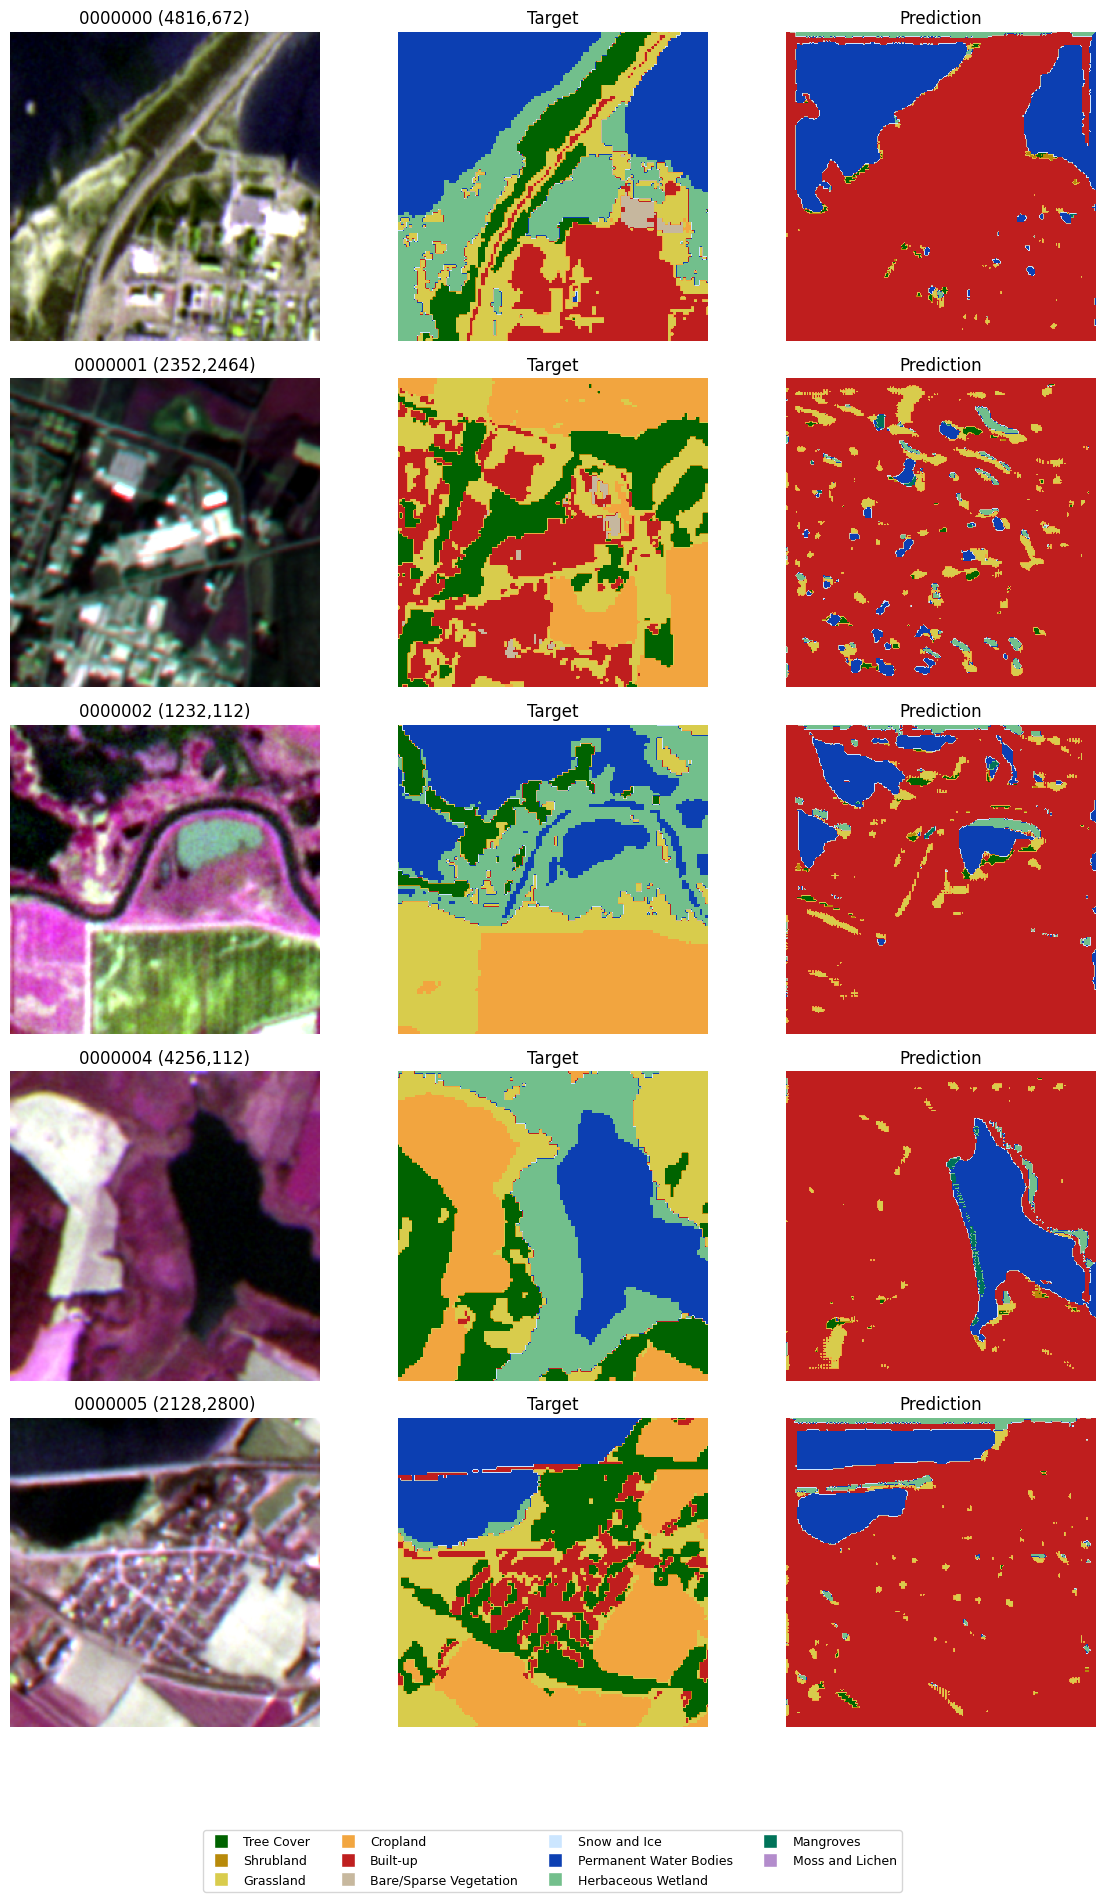

In [12]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm


def render_rgb(image_chw: np.ndarray, bands: tuple[int, int, int] = RGB_BANDS) -> np.ndarray:
    available = image_chw.shape[0]
    if max(bands) >= available:
        bands = tuple(range(min(3, available)))
    rgb = np.stack([image_chw[idx] for idx in bands], axis=-1)
    lo = np.nanpercentile(rgb, 2, axis=(0, 1), keepdims=True)
    hi = np.nanpercentile(rgb, 98, axis=(0, 1), keepdims=True)
    return np.clip((rgb - lo) / (hi - lo + 1e-6), 0.0, 1.0)


cmap = ListedColormap(CLASS_COLORS)
norm = BoundaryNorm(np.arange(len(CLASS_NAMES) + 1) - 0.5, cmap.N)

n_rows = len(records)
fig, axes = plt.subplots(n_rows, 3, figsize=(12, 3.8 * n_rows), squeeze=False)
for row_idx, record in enumerate(records):
    panels = [
        (render_rgb(record["image"]), "Image"),
        (record["label"], "Target"),
        (pred_class[row_idx], "Prediction"),
    ]
    for col_idx, (panel, title) in enumerate(panels):
        ax = axes[row_idx, col_idx]
        if col_idx == 0:
            ax.imshow(panel)
            top, left = record["crop_origin"]
            ax.set_title(f"{record['sample_id']} ({top},{left})")
        else:
            shown = np.ma.masked_where(panel == IGNORE_INDEX, panel)
            ax.imshow(shown, cmap=cmap, norm=norm)
            ax.set_title(title)
        ax.axis("off")

handles = [plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=CLASS_COLORS[idx], markersize=10, label=CLASS_NAMES[idx]) for idx in range(len(CLASS_NAMES))]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=9)
fig.tight_layout(rect=(0, 0.08, 1, 1))
output_path = OUTPUT_DIR / "land_cover_validation_montage.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
print(f"saved: {output_path}")
plt.show()


## Render Artifact Diagnostic Images

These figures save the preprocessing and smoothing comparisons used to interpret the stripe artifacts. The smoothing preview is not used as the primary prediction.


saved: /Users/roberto.delprete/.cache/hydranet/land_cover/outputs/land_cover_preprocess_variant_check.png


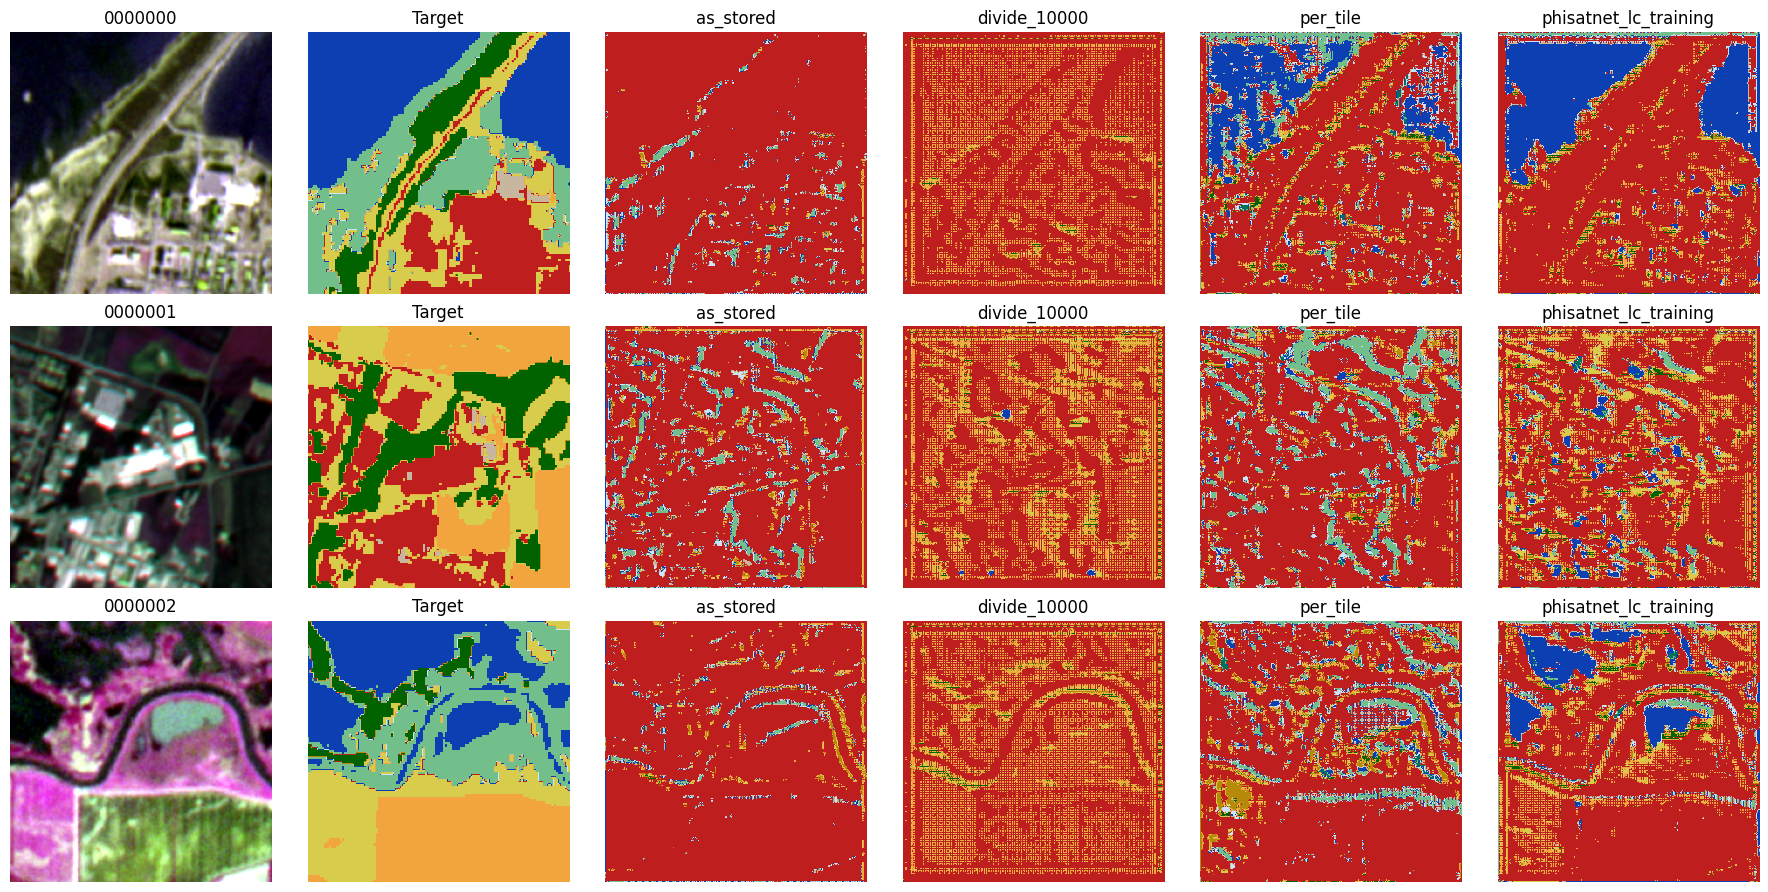

saved: /Users/roberto.delprete/.cache/hydranet/land_cover/outputs/land_cover_smoothing_check.png


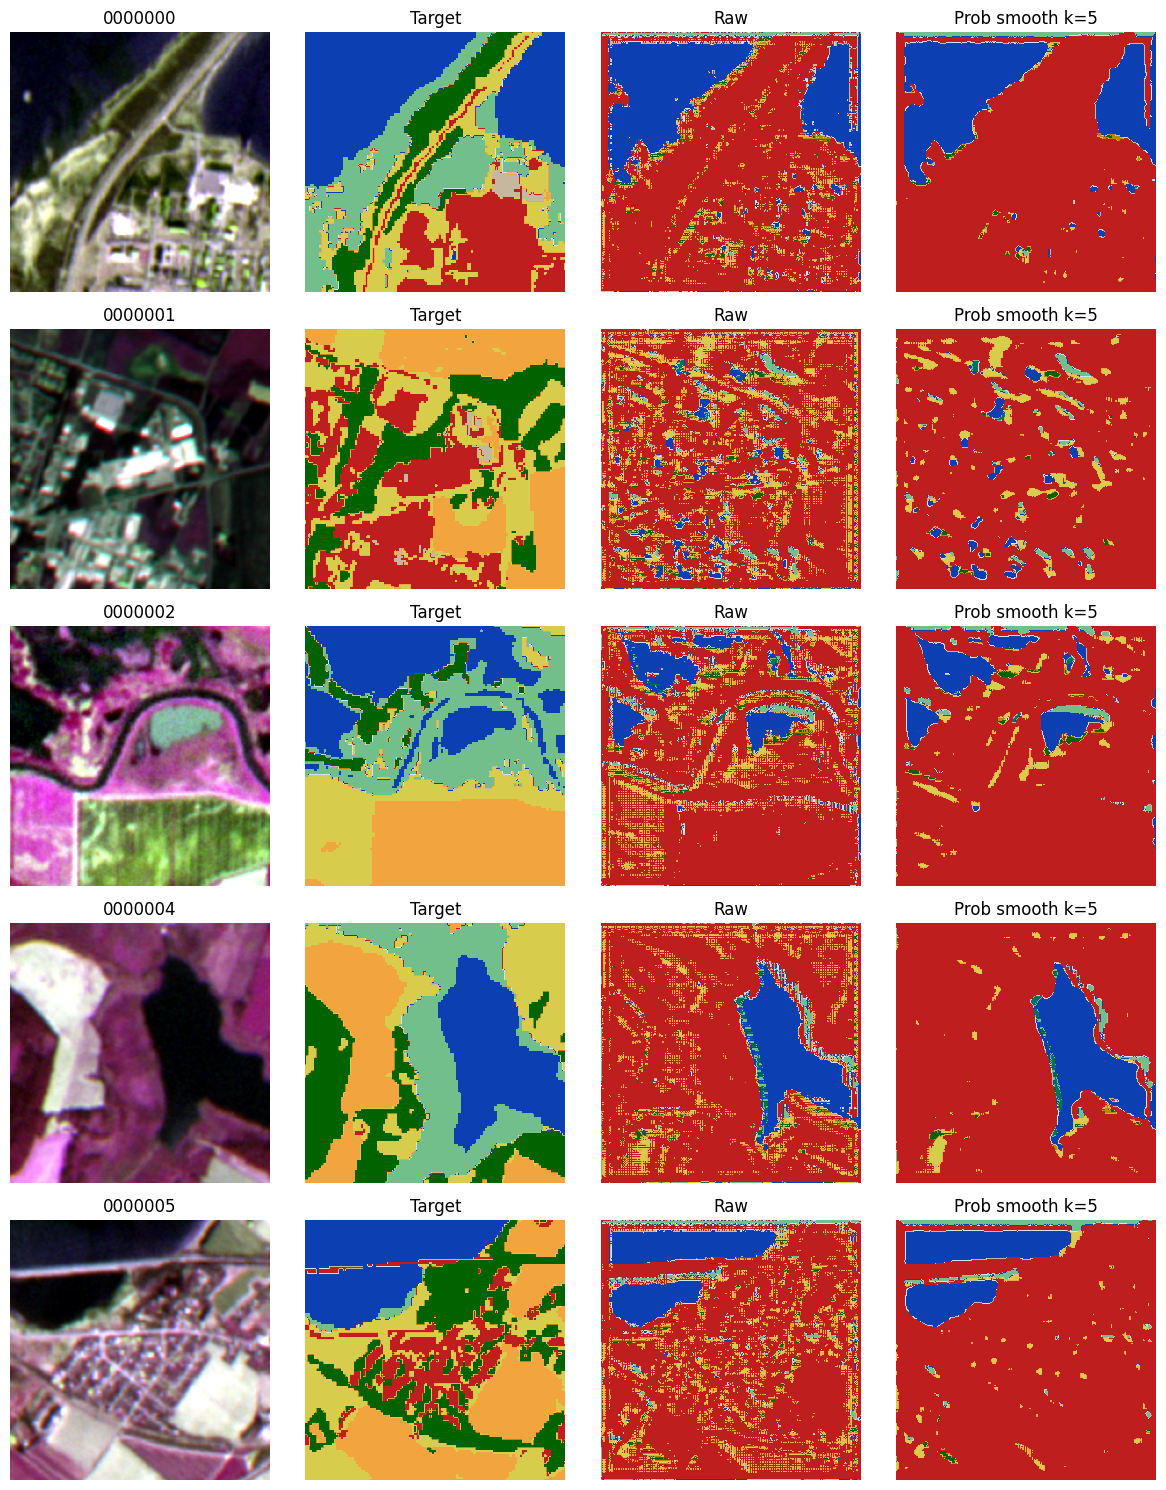

In [13]:
preview_records = records[:min(3, len(records))]
variant_names = [mode for mode in ARTIFACT_AUDIT_NORMALIZATION_MODES if mode in normalization_predictions]
fig, axes = plt.subplots(
    len(preview_records),
    2 + len(variant_names),
    figsize=(3.0 * (2 + len(variant_names)), 3.0 * len(preview_records)),
    squeeze=False,
)
for row_idx, record in enumerate(preview_records):
    panels = [(render_rgb(record["image"]), record["sample_id"]), (record["label"], "Target")]
    panels.extend((normalization_predictions[mode][row_idx], mode.replace("per_tile_channel_standardization", "per_tile")) for mode in variant_names)
    for col_idx, (panel, title) in enumerate(panels):
        ax = axes[row_idx, col_idx]
        if col_idx == 0:
            ax.imshow(panel)
        else:
            ax.imshow(np.ma.masked_where(panel == IGNORE_INDEX, panel), cmap=cmap, norm=norm)
        ax.set_title(title)
        ax.axis("off")
fig.tight_layout()
preprocess_output_path = OUTPUT_DIR / "land_cover_preprocess_variant_check.png"
fig.savefig(preprocess_output_path, dpi=160, bbox_inches="tight")
print(f"saved: {preprocess_output_path}")
plt.show()

if SMOOTHED_PREVIEW_KERNEL in smoothed_predictions:
    smoothed_preview = smoothed_predictions[SMOOTHED_PREVIEW_KERNEL]
    fig, axes = plt.subplots(len(records), 4, figsize=(12, 3.0 * len(records)), squeeze=False)
    for row_idx, record in enumerate(records):
        panels = [
            (render_rgb(record["image"]), record["sample_id"]),
            (record["label"], "Target"),
            (raw_pred_class[row_idx], "Raw"),
            (smoothed_preview[row_idx], f"Prob smooth k={SMOOTHED_PREVIEW_KERNEL}"),
        ]
        for col_idx, (panel, title) in enumerate(panels):
            ax = axes[row_idx, col_idx]
            if col_idx == 0:
                ax.imshow(panel)
            else:
                ax.imshow(np.ma.masked_where(panel == IGNORE_INDEX, panel), cmap=cmap, norm=norm)
            ax.set_title(title)
            ax.axis("off")
    fig.tight_layout()
    smoothing_output_path = OUTPUT_DIR / "land_cover_smoothing_check.png"
    fig.savefig(smoothing_output_path, dpi=160, bbox_inches="tight")
    print(f"saved: {smoothing_output_path}")
    plt.show()
else:
    print(f"SMOOTHED_PREVIEW_KERNEL={SMOOTHED_PREVIEW_KERNEL} was not in SMOOTHING_AUDIT_KERNELS")


## Quick Failure Checks

Use these checks before interpreting accuracy numbers:

- If the archive download is too slow, download `phileo-bench_lc.zarr.zip` once outside the notebook and place it at `ARCHIVE_PATH`.
- If labels render as one color or all ignored, inspect raw `np.unique(label)` values and update `CODE_TO_CLASS_ID` if the dataset encoding differs.
- Do not remap classes from empirical confusion alone. Phi2FM maps WorldCover code `80` to model class `7`, so water is already the eighth output channel.
- The current checkpoint is pinned to `linear_probing`, `50` shots, date `20251228`; do not switch back to `latest_only=True` without rechecking `edge_rate_mean`.
- Dense stripe or checkerboard predictions with high `edge_rate_mean` are checkpoint/preprocessing artifacts, not a target/prediction label-order swap.
- The main prediction uses probability smoothing with `PREDICTION_SMOOTHING_KERNEL=5` to suppress residual decoder speckle; the raw `k=0` output remains in the diagnostics.
- The selected crops are a smoke test, not a benchmark. Increase `N_SAMPLES` or iterate all samples for a real validation number.
